<a href="https://colab.research.google.com/github/adrianfelsky/TrabalhoRedesNeurais26-2/blob/main/Trabalho_Redes_Neurais_(Yan_e_Adrian).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##UFSC - Campus Blumenau
##Disciplina: CAC8002 - Inteligência Artificial

Alunos:

Adrian Gazzani Felsky dos Anjos

Yan Claus Fructuoso

# Exercício 1

In [17]:

import pandas as pd

# URL raw do arquivo audit_risk.csv no seu GitHub
#audit_risk_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/audit_risk_PADRONIZADO.csv'
#trial_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/trial_correcao_PADRONIZADO.csv'

# Caso decida verificar os bancos originais, antes do tratamento dos dados (e remoção de parâmetros incompatíveis),
# basta comentar os urls acima, e descomentar os abaixo:

audit_risk_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/audit_risk_TESTELEITURA4.csv'
trial_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/trial_correcao.csv'


# Carregando o dataset
audit_risk = pd.read_csv(audit_risk_url)
trial = pd.read_csv(trial_url)

print("\nDataset audit_risk:")
print(audit_risk)

print("\nDataset trial:")
print(trial)


Dataset audit_risk:
     Sector_score  LOCATION_ID  PARA_A  Score_A  Risk_A  PARA_B  Score_B1  \
0            3.89           23    4.18      0.6   2.508    2.50       0.2   
1            3.89            6    0.00      0.2   0.000    4.83       0.2   
2            3.89            6    0.51      0.2   0.102    0.23       0.2   
3            3.89            6    0.00      0.2   0.000   10.80       0.6   
4            3.89            6    0.00      0.2   0.000    0.08       0.2   
..            ...          ...     ...      ...     ...     ...       ...   
768         55.57            9    0.49      0.2   0.098    0.40       0.2   
769         55.57           16    0.47      0.2   0.094    0.37       0.2   
770         55.57           14    0.24      0.2   0.048    0.04       0.2   
771         55.57           18    0.20      0.2   0.040    0.00       0.2   
772         55.57           15    0.00      0.2   0.000    0.00       0.2   

     Risk_B  TOTAL  numbers  ...  RiSk_E  History  Pro

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

import ipdb
!pip install ipdb

ModuleNotFoundError: No module named 'ipdb'

In [ ]:
# >> ENUNCIADO <<

# Definir uma rede neural para classificar as instâncias dos datasets abaixo.

# O resultado deve apresentar a taxa de acerto (accuracy) e a matriz de confusão. Separar
# instâncias de treinamento e teste. Usar o classificador J48 (árvore de decisão) para
# comparar o resultado (que pode ser executado no Weka) e colocar a comparação no colab
# (pode ser print de tela do Weka).


import math

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from keras import layers
from keras import regularizers

import numpy as np
from numpy import loadtxt

import sklearn
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import KFold

import pandas as pd
import keras
# keras.__version__ # 3.12.1

                #w = weight
def predict(row, w):

  act = w[0]
  rowSum = 0

  for i in range(len(row)-1):
#    rowSum = 0
#
#    for j in range(len(row)-1):
#      rowSum += row[i][j]
#    print(w[i+1], i, row[i])
    act += w[i+1] * row[i]
    print(act)

  #return 1.0 if 1 / (1 + math.exp(-act)) > 0.5 else 0  # sigmoid - retirado do exemplo do professor
  return 1.0 if act >=0 else 0.0 # Relu


def trainWeights(trainSet, learnRte, nEpoch): # {

  #OBS.: estou usando a terminologia que vimos na matéria
  w = [0.0 for i in range(len(trainSet[0]))] # inicia tudo como 0 (pra iniciar tudo aleatório, tem o exemplo do professor)


  #print(trainSet)

  for epoch in range(nEpoch):

    sumErr = 0

    for row in trainSet:

      error = predict(row,w) - row[len(row)-1]
      sumErr += error**2
#     w[0] += error * learnRte
#      w[epoch] = w[epoch] + (error) * learnRte

      for i in range(len(row)-1):
        w[i + 1] = w[i] + learnRte * error * row[i]

        print('> epoch=%d, lrate=%.3f, error=%.3f\n' % (epoch, learnRte, sumErr))
  return w
# }

# INFOS IMPORTANTES: variável de classificação == "risk" (a final, com 0 ou 1)
#                       '-> no caso, presumo que 0 == firma normal, 1 == golpista




In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, Normalizer

from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# URL raw do arquivo audit_risk.csv no GitHub
# audit_risk_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/audit_risk_TESTELEITURA4.csv'
# trial_url = 'https://raw.githubusercontent.com/adrianfelsky/TrabalhoRedesNeurais26-2/main/exercicio1/audit_data/trial_correcao.csv'
# Carregando o dataset
#audit_risk = pd.read_csv(audit_risk_url)
#trial = pd.read_csv(trial_url)
#
#print("\nDataset audit_risk:")
#print(audit_risk)
#
#print("\nDataset trial:")
#print(trial)


# --------- TREINAMENTO ---------------------------------

# Fazendo o pré-processamento dos dados, para todos estarem entre 0 e 1
scaler = MinMaxScaler(feature_range=(0, 1))
#audit_dataset_norm = Normalizer().fit(audit_risk)
audit_dataset = scaler.fit_transform(audit_risk)#audit_dataset_norm)



learnRate = 0.3
numEpoch = 201

weights = trainWeights(audit_dataset, learnRate, numEpoch)

#print(weights)
# -------------------------------------------------------




# --------- TESTE -----------------------------
predVal = [0.0 for i in range(len(trial[0]))]
print("predval: ", predVal)

trueVal = [0.0 for i in range(len(trial[0]))]
print("trueVal: ", trueVal)

trueVal[i] = trial[:, 26]

for i in range(len(trial)-1):
 predVal[i] = predict(trial[i],w)



print("predval: ", predVal)
print("trueVal: ", trueVal)

confMatrix = metrics.confusion_matrix(trueVal, predVal)

tn, fp, fn, tp = confMatrix.ravel()

#print(confMatrix)

confMatrixDisplay = ConfusionMatrixDisplay(confusion_matrix = confMatrix, display_labels = [0, 1])


confMatrixDisplay.plot()
plt.show()

# ---------------------------------------------



A saída de streaming foi truncada nas últimas 5000 linhas.

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

> epoch=200, lrate=0.300, error=327.000

0.2573577645659928
0.2937235540887544
0.2951217117377001
0.2951217117377001
0.2952428898190748
0.2952428898190748
0.29545731703393585
0.29545731703393585
0.29545731703393585
0.29545731703393585
0.29545731703393585
> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, error=328.000

> epoch=200, lrate=0.300, err

KeyError: 0

In [24]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
from keras import layers
from keras import regularizers

import numpy as np
from numpy import loadtxt

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import KFold
import pandas as pd
import keras

#separando o dataset de treino em inputs (parâmetros) e outputs (saídas):
print(audit_risk.shape) # output --> "(773, 27)"

X = audit_risk[:, 0:26]
Y = audit_risk[:, 26]

#print(X)
#print(Y)

(773, 27)


InvalidIndexError: (slice(None, None, None), slice(0, range(0, 772), None))

In [ ]:
audit_risk

,Sector_score,LOCATION_ID,PARA_A,SCORE_A,PARA_B,SCORE_B,TOTAL,numbers,Money_Value,History,Score,Risk
0,3.89,23,4.18,6,2.50,2,6.68,5.0,3.38,0,2.4,1
1,3.89,6,0.00,2,4.83,2,4.83,5.0,0.94,0,2.0,0
2,3.89,6,0.51,2,0.23,2,0.74,5.0,0.00,0,2.0,0
3,3.89,6,0.00,2,10.80,6,10.80,6.0,11.75,0,4.4,1
4,3.89,6,0.00,2,0.08,2,0.08,5.0,0.00,0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
768,55.57,9,0.49,2,0.40,2,0.89,5.0,0.00,0,2.0,0
769,55.57,16,0.47,2,0.37,2,0.84,5.0,0.00,0,2.0,0
770,55.57,14,0.24,2,0.04,2,0.28,5.0,0.00,0,2.0,0
771,55.57,18,0.20,2,0.00,2,0.20,5.0,0.00,0,2.0,0


In [ ]:
trial

,Sector_score,LOCATION_ID,PARA_A,SCORE_A,PARA_B,SCORE_B,TOTAL,numbers,Money_Value,History,Score,Risk
0,3.89,23,4.18,6,2.50,2,6.68,5.0,3.38,0,2.4,1
1,3.89,6,0.00,2,4.83,2,4.83,5.0,0.94,0,2.0,0
2,3.89,6,0.51,2,0.23,2,0.74,5.0,0.00,0,2.0,0
3,3.89,6,0.00,2,10.80,6,10.80,6.0,11.75,0,4.4,1
4,3.89,6,0.00,2,0.08,2,0.08,5.0,0.00,0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
768,55.57,9,0.49,2,0.40,2,0.89,5.0,0.00,0,2.0,0
769,55.57,16,0.47,2,0.37,2,0.84,5.0,0.00,0,2.0,0
770,55.57,14,0.24,2,0.04,2,0.28,5.0,0.00,0,2.0,0
771,55.57,18,0.20,2,0.00,2,0.20,5.0,0.00,0,2.0,0


_Simulação do Weka:_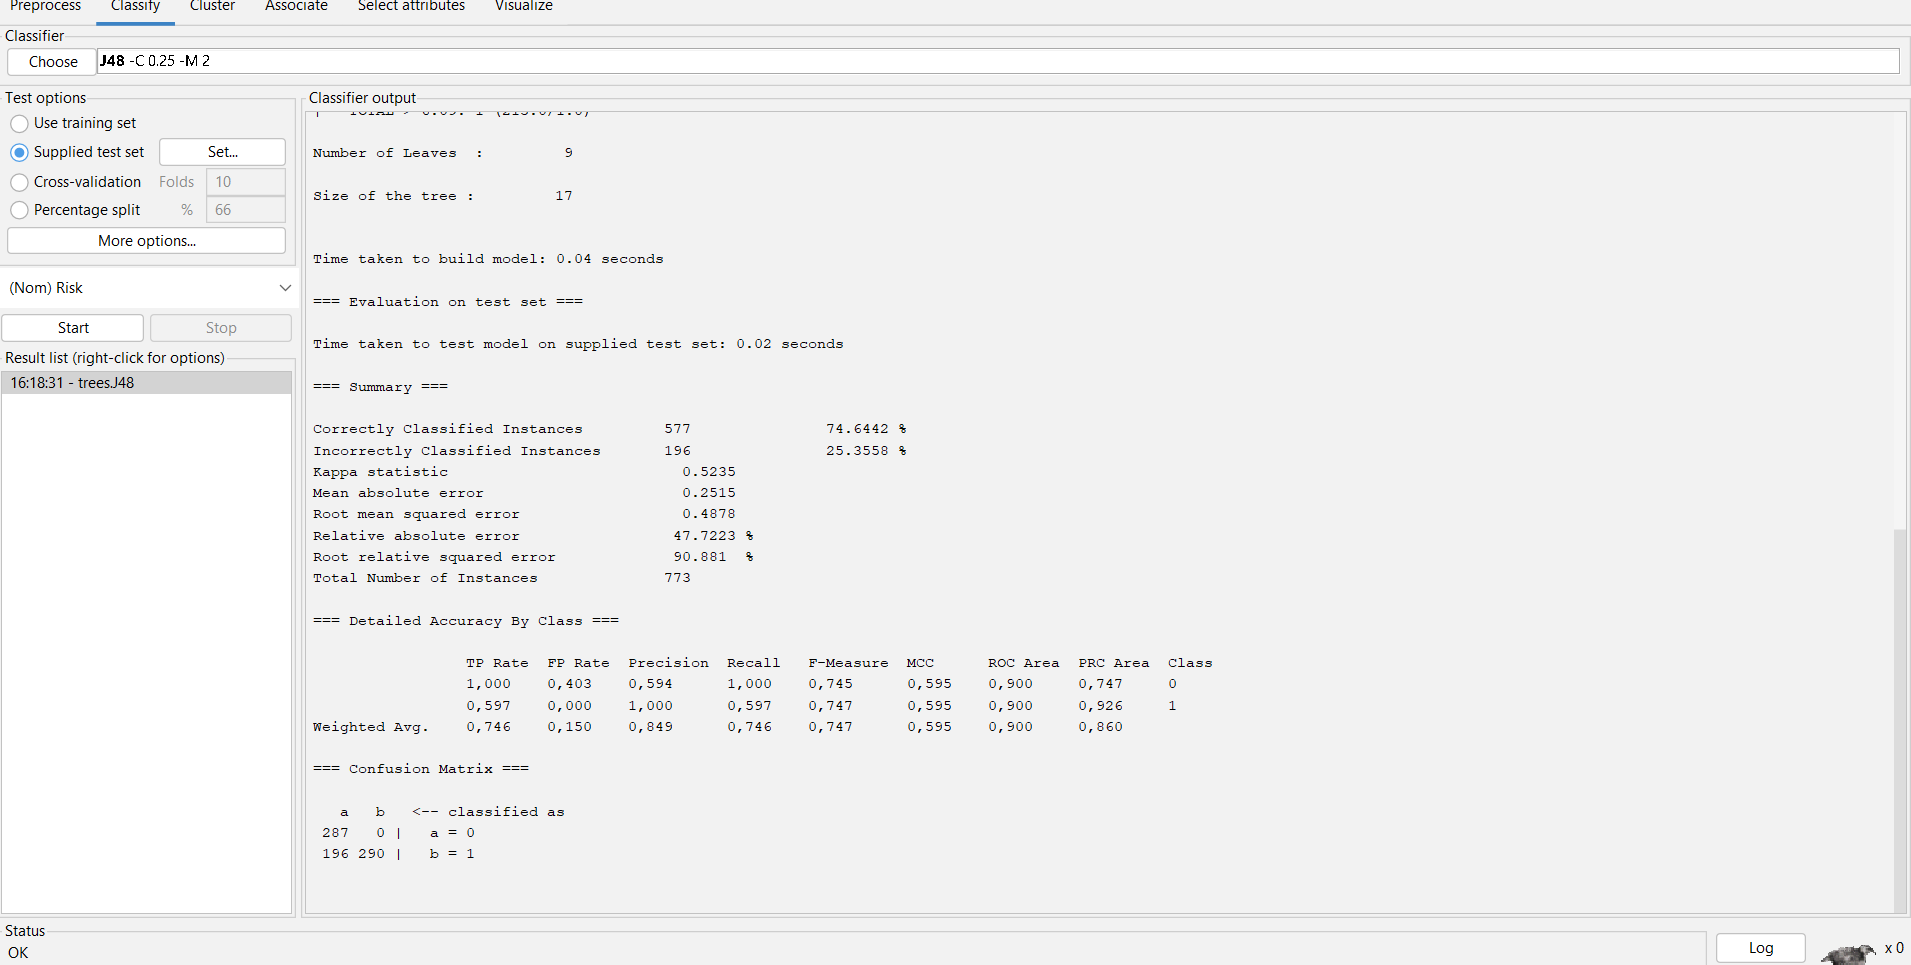

# Exercício 2

In [ ]:
# Caso aja erro na importação dos datasets de imagem de treino, descomente as duas linhas abaixo
!git clone https://github.com/adrianfelsky/TrabalhoRedesNeurais26-2
!mv ./TrabalhoRedesNeurais26-2/ datasets

# Importar bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configurar os caminhos e carregar as imagens
caminho_treino = '/content/datasets/exercicio2/dataset/treino'
caminho_teste = '/content/datasets/exercicio2/dataset/teste'

tamanho_lote = 32
altura_img = 150
largura_img = 150

# Carregar os datasets
dataset_treino = tf.keras.utils.image_dataset_from_directory(
  caminho_treino,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

dataset_teste = tf.keras.utils.image_dataset_from_directory(
  caminho_teste,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

nomes_classes = dataset_treino.class_names
print(f"Classes carregadas: {nomes_classes}")

# Otimização de performance no carregamento
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_teste = dataset_teste.cache().prefetch(buffer_size=AUTOTUNE)

# Construir a Rede Neural Convolucional (CNN)
# Incluindo camadas de Data Augmentation para ajudar a atingir a meta de >90% de acurácia
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(altura_img, largura_img, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

modelo = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5),
  layers.Dense(len(nomes_classes), activation='softmax')
])

modelo.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Treinar a Rede com Early Stopping
epocas = 25

historico = modelo.fit(
  dataset_treino,
  validation_data=dataset_teste,
  epochs=epocas
)

# Avaliar o modelo e apresentar a Acurácia
perda, acuracia = modelo.evaluate(dataset_teste)
print(f"\n--- RESULTADO FINAL ---")
print(f"Acurácia no Dataset de Teste: {acuracia * 100:.2f}%")

# Gerar a Matriz de Confusão
y_verdadeiro = []
y_previsto = []

# Iterar sobre o dataset de teste para pegar as previsões
for imagens, rotulos in dataset_teste:
    y_verdadeiro.extend(rotulos.numpy())
    previsoes = modelo.predict(imagens, verbose=0)
    y_previsto.extend(np.argmax(previsoes, axis=-1))

matriz = confusion_matrix(y_verdadeiro, y_previsto)

# Plotar a Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão: Barco vs Avião")
plt.show()

Cloning into 'TrabalhoRedesNeurais26-2'...
remote: Enumerating objects: 1230, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 1230 (delta 1), reused 2 (delta 0), pack-reused 1224 (from 2)
Receiving objects: 100% (1230/1230), 89.84 MiB | 35.32 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Found 960 files belonging to 2 classes.
Found 240 files belonging to 2 classes.
Classes carregadas: ['aviao', 'barco']
Epoch 1/25


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 